# 📊 Chapter 1: Exploratory Data Analysis (EDA)
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Author:** Dhafi Dzakwan Pratama | 101032300213
> **Topik:** Estimasi Lokasi, Estimasi Variabilitas, Distribusi Data, dan Korelasi
---
## 1. Import Library dan Memuat Data
Buku ini menggunakan bahasa Python dan R. Pada notebook ini, kita akan menggunakan *library* standar Data Science di Python (`pandas`, `numpy`, `scipy`, `statsmodels`). Kita akan mensimulasikan dataset state population yang biasa dipakai di bab ini.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Simulasi cuplikan dataset 'state.csv' dari buku
data = {'State': ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware'],
        'Population': [4779736, 710231, 6392017, 2915918, 37253956, 5029196, 3574097, 897934],
        'Murder.Rate': [5.7, 5.6, 4.7, 5.6, 4.4, 2.8, 2.4, 5.8]}
state = pd.DataFrame(data)
state.head()

,State,Population,Murder.Rate
0,Alabama,4779736,5.7
1,Alaska,710231,5.6
2,Arizona,6392017,4.7
3,Arkansas,2915918,5.6
4,California,37253956,4.4


## 2. Estimates of Location (Estimasi Lokasi)
Estimasi lokasi berguna untuk mengukur kecenderungan sentral data.
- **Mean:** Rata-rata biasa (rentan outlier).
- **Trimmed Mean:** Rata-rata setelah membuang sebagian persen nilai terkecil dan terbesar (lebih kebal outlier).
- **Median:** Nilai tengah data saat diurutkan (paling kebal outlier).

In [2]:
# Menghitung Mean
mean_pop = state['Population'].mean()

# Menghitung Trimmed Mean (Memotong 10% nilai atas dan bawah)
trim_mean_pop = trim_mean(state['Population'], 0.1)

# Menghitung Median
median_pop = state['Population'].median()

print(f"Mean Populasi: {mean_pop:,.0f}")
print(f"Trimmed Mean Populasi: {trim_mean_pop:,.0f}")
print(f"Median Populasi: {median_pop:,.0f}")

Mean Populasi: 7,694,136
Trimmed Mean Populasi: 7,694,136
Median Populasi: 4,176,916


## 3. Estimates of Variability (Estimasi Variabilitas)
Mengukur seberapa menyebar data dari pusatnya.
- **Standard Deviation:** Standar deviasi biasa.
- **IQR (Interquartile Range):** Selisih kuartil 3 dan kuartil 1 (tahan outlier).
- **MAD (Median Absolute Deviation):** Rata-rata jarak absolut dari median.

In [3]:
# Standar Deviasi
std_pop = state['Population'].std()

# Interquartile Range (IQR) = Q3 - Q1
iqr_pop = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

# Median Absolute Deviation (MAD)
mad_pop = robust.scale.mad(state['Population'])

print(f"Standard Deviation: {std_pop:,.0f}")
print(f"IQR: {iqr_pop:,.0f}")
print(f"MAD: {mad_pop:,.0f}")

Standard Deviation: 12,105,745
IQR: 2,958,479
MAD: 2,576,836


## 4. Exploring the Data Distribution (Distribusi Data)
Distribusi digunakan untuk melihat rentang, pemusatan, dan skewness data. *Boxplot* sangat ideal untuk mendeteksi *outlier* dengan cepat (misalnya populasi California yang ekstrem besarnya dibandingkan negara bagian lain).

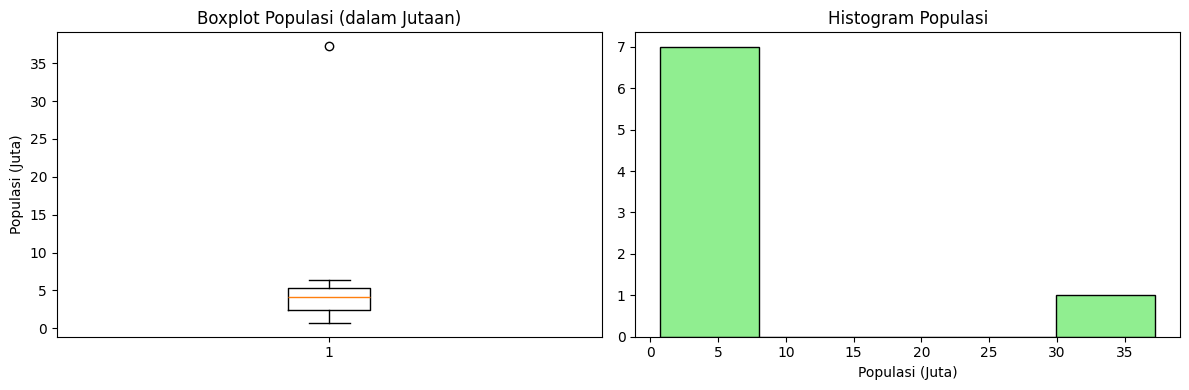

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
ax[0].boxplot(state['Population'] / 1_000_000)
ax[0].set_title('Boxplot Populasi (dalam Jutaan)')
ax[0].set_ylabel('Populasi (Juta)')

# Histogram
ax[1].hist(state['Population'] / 1_000_000, bins=5, color='lightgreen', edgecolor='black')
ax[1].set_title('Histogram Populasi')
ax[1].set_xlabel('Populasi (Juta)')

plt.tight_layout()
plt.show()

## 5. Correlation (Korelasi)
Korelasi mengevaluasi hubungan linier antar dua variabel. Jika positif, jika satu variabel naik, variabel lain ikut naik.

Matriks Korelasi:
          Telecom   Verizon
Telecom  1.000000  0.811551
Verizon  0.811551  1.000000


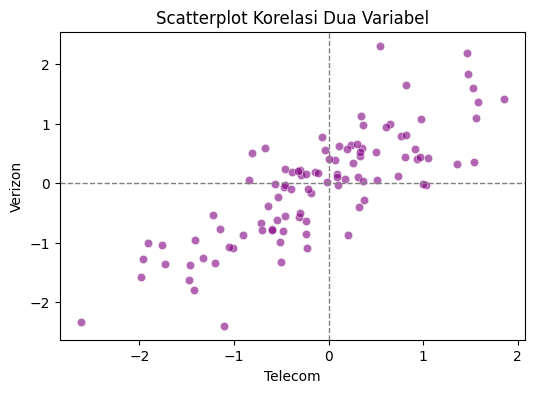

In [5]:
# Dataset dummy untuk simulasi harga saham Telecom vs Verizon dari buku
np.random.seed(42)
telecom = pd.DataFrame({
    'Telecom': np.random.normal(0, 1, 100),
    'Verizon': np.random.normal(0, 1, 100)
})
telecom['Verizon'] = telecom['Telecom'] * 0.7 + np.random.normal(0, 0.5, 100) # Membangun korelasi positif

# Matriks Korelasi (Pearson)
print("Matriks Korelasi:")
print(telecom.corr())

# Scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Telecom', y='Verizon', data=telecom, color='purple', alpha=0.6)
plt.title('Scatterplot Korelasi Dua Variabel')
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.axvline(0, color='grey', lw=1, linestyle='--')
plt.show()